# Carregamento dos Dados e Modelos

In [11]:
import pandas as pd
import glob
import joblib
import os
from sklearn.model_selection import train_test_split

# 1. Carregamento dos dados
caminho_dados = os.path.join('..', 'data', '*.csv')
arquivos = glob.glob(caminho_dados)
lista_dfs = []

for f in arquivos:
    if 'data.ipynb' in f: continue
    df_temp = pd.read_csv(f)
    lista_dfs.append(df_temp)

df_proc = pd.concat(lista_dfs, ignore_index=True)

# 2. ENGENHARIA DE ATRIBUTOS 
# Criando as colunas de 'slope' (variação entre linhas)
df_proc['mq3_slope'] = df_proc['mq3_raw'].diff().fillna(0)
df_proc['temp_slope'] = df_proc['temperatura'].diff().fillna(0)
df_proc['umid_slope'] = df_proc['umidade_ar'].diff().fillna(0)

# 3. Seleção das Colunas 
colunas_modelo = ['mq3_raw', 'temperatura', 'umidade_ar', 'mq3_slope', 'temp_slope', 'umid_slope']

X = df_proc[colunas_modelo]
y = df_proc['validade'].fillna(0) 

# 4. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Carregar modelos
modelo_estado = joblib.load('modelo_1_estado.pkl')
modelo_tempo = joblib.load('modelo_2_tempo_restante.pkl')

print("Colunas ajustadas com Sucesso!")

Colunas ajustadas com Sucesso!


# 1. Relatório de Classificação e Matriz de Confusão

--- RELATÓRIO DE CLASSIFICAÇÃO: ESTADO DA FRUTA ---
              precision    recall  f1-score   support

         0.0       0.99      0.72      0.83       269
         1.0       0.00      0.00      0.00         0
         2.0       0.00      0.00      0.00         0
        12.0       0.00      0.00      0.00         8
        48.0       0.00      0.00      0.00         3

    accuracy                           0.69       280
   macro avg       0.20      0.14      0.17       280
weighted avg       0.95      0.69      0.80       280



c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

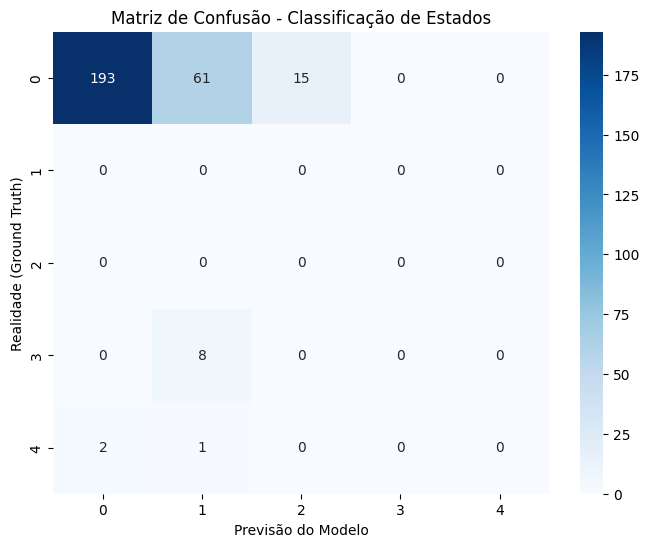

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Gerar as previsões 
y_pred_estado = modelo_estado.predict(X_test)

# 2. Relatório de Precision, Recall e F1-Score
# Nota: O y_test deve conter as categorias (labels) que o modelo espera
print("--- RELATÓRIO DE CLASSIFICAÇÃO: ESTADO DA FRUTA ---")
print(classification_report(y_test, y_pred_estado))

# 3. Matriz de Confusão Visual
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_estado)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Classificação de Estados')
plt.ylabel('Realidade (Ground Truth)')
plt.xlabel('Previsão do Modelo')
plt.show()

# 2. Desafio da Regressão

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Criar um modelo básico (Baseline) para comparação
reg_linear = LinearRegression().fit(X_train, y_train)

# Previsões
y_pred_ia = modelo_tempo.predict(X_test)
y_pred_linear = reg_linear.predict(X_test)

print("--- COMPARAÇÃO DE PREVISÃO DE VALIDADE (HORAS) ---")
print(f"Erro Médio da IA (Random Forest): {mean_absolute_error(y_test, y_pred_ia):.2f} horas")
print(f"Erro Médio da Regressão Linear: {mean_absolute_error(y_test, y_pred_linear):.2f} horas")
print(f"R2 Score da IA: {r2_score(y_test, y_pred_ia):.2f}")

--- COMPARAÇÃO DE PREVISÃO DE VALIDADE (HORAS) ---
Erro Médio da IA (Random Forest): 3.92 horas
Erro Médio da Regressão Linear: 2.20 horas
R2 Score da IA: -0.24


# 3. Curva ROC e Limiar de Discriminação

c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


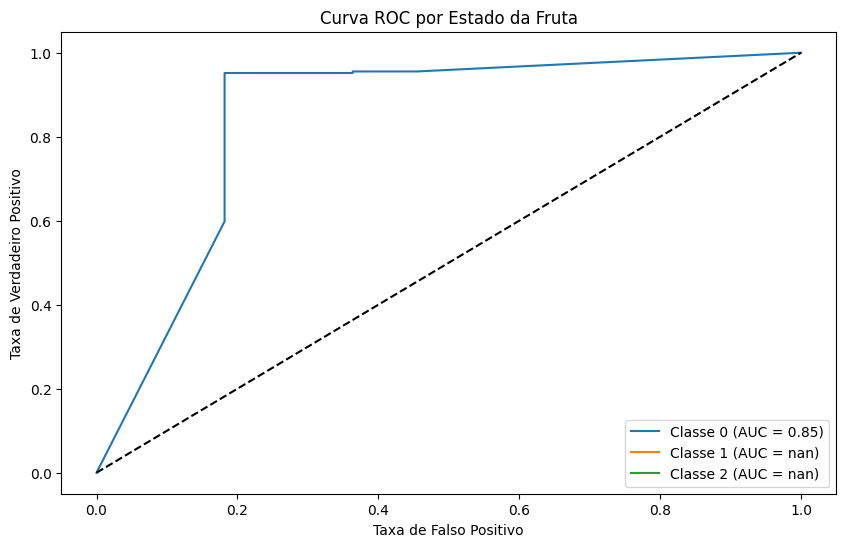

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarizar o y_test para curva multiclasse
y_test_bin = label_binarize(y_test, classes=modelo_estado.classes_)
y_score = modelo_estado.predict_proba(X_test)

# Plotar ROC para cada estado
plt.figure(figsize=(10, 6))
for i, classe in enumerate(modelo_estado.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f'Classe {classe} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Taxa de Falso Positivo')
plt.ylabel('Taxa de Verdadeiro Positivo')
plt.title('Curva ROC por Estado da Fruta')
plt.legend()
plt.show()

# Feature Importance

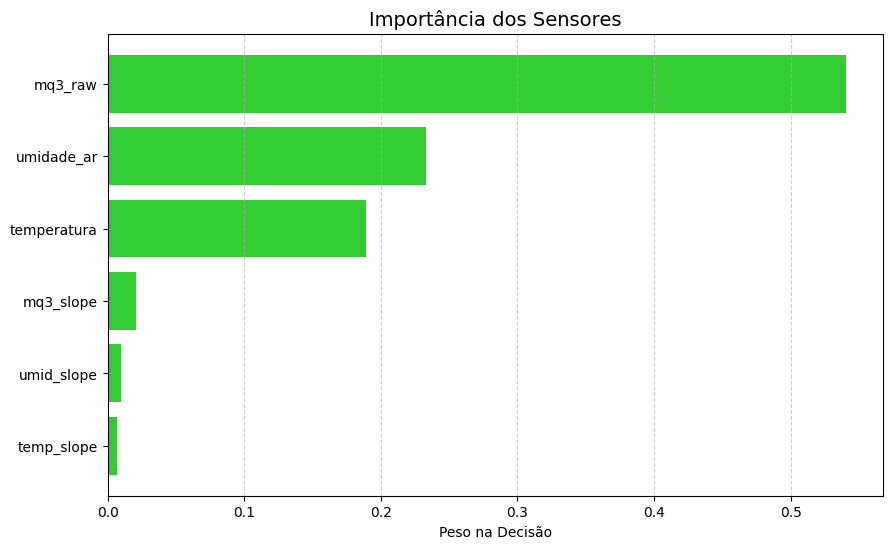

✅ Gráfico gerado e salvo como 'feature_importances.png'


In [15]:
import matplotlib.pyplot as plt
import numpy as np
import joblib
import pandas as pd

# 1. Garantir que o Modelo e o X existam
try:
    if 'modelo_estado' not in locals():
        modelo_estado = joblib.load('modelo_1_estado.pkl')
    
    # Se X não existir, precisamos definir as colunas que o modelo espera
    if 'X' not in locals():
        colunas_modelo = ['mq3_raw', 'temperatura', 'umidade_ar', 'mq3_slope', 'temp_slope', 'umid_slope']
        
        # Se você já tem o df_proc carregado, criamos o X dele
        if 'df_proc' in locals():
            X = df_proc[colunas_modelo]
        else:
            print("ERRO: df_proc não encontrado. Rode a célula 'Carregamento dos Dados e Modelos' primeiro!")

    # 2. Extrair Importância (Lidando com Pipeline do sklearn)
    # Se o modelo estiver dentro de um Pipeline (com scaler), pegamos o último passo
    if hasattr(modelo_estado, 'steps'):
        importancias = modelo_estado.steps[-1][1].feature_importances_
    else:
        importancias = modelo_estado.feature_importances_

    atributos = colunas_modelo
    indices = np.argsort(importancias)

    # 3. Gerar o Gráfico
    plt.figure(figsize=(10, 6))
    plt.title('Importância dos Sensores', fontsize=14)
    plt.barh(range(len(indices)), importancias[indices], color='limegreen', align='center')
    plt.yticks(range(len(indices)), [atributos[i] for i in indices])
    plt.xlabel('Peso na Decisão')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    # Salvar a imagem para o relatório
    plt.savefig('feature_importances.png', bbox_inches='tight')
    plt.show()
    
    print("✅ Gráfico gerado e salvo como 'feature_importances.png'")

except Exception as e:
    print(f"Erro crítico: {e}")

In [16]:
import joblib
import pandas as pd
import os
import glob
import datetime
from sklearn.metrics import classification_report, mean_absolute_error, r2_score

# 1. Ajuste de dados e previsões
df_proc['estado_real_ajustado'] = df_proc['estado_real'].replace('sem risco', 'ambiente').fillna('ambiente')
y_test_nomes = df_proc.loc[y_test.index, 'estado_real_ajustado']

encoder_estado = joblib.load('encoder_estado.pkl')
y_pred_num = modelo_estado.predict(X_test)
y_pred_nomes = encoder_estado.inverse_transform(y_pred_num)

y_pred_tempo = modelo_tempo.predict(X_test)
mae_ia = mean_absolute_error(y_test, y_pred_tempo)
r2_ia = r2_score(y_test, y_pred_tempo)

agora = datetime.datetime.now()
data_hoje = agora.strftime("%d/%m/%Y %H:%M")

# 2. Lógica de numeração automática
pasta_atual = os.getcwd()
arquivos_existentes = glob.glob("relatorio_*.md")

proximo_numero = 1
if arquivos_existentes:
    # Extrai os números dos nomes dos arquivos 'relatorio_X.md'
    numeros = []
    for f in arquivos_existentes:
        try:
            # Pega o que está entre o '_' e o '.'
            num = int(f.split('_')[1].split('.')[0])
            numeros.append(num)
        except:
            continue
    if numeros:
        proximo_numero = max(numeros) + 1

nome_arquivo = f"relatorio_{proximo_numero}.md"

# 3. Montagem do conteúdo (Linha por linha para evitar erros no Jupyter)
report_text = classification_report(y_test_nomes, y_pred_nomes)

linhas = []
linhas.append(f"# Relatório de Validação #{proximo_numero}: Monitoramento das Frutas")
linhas.append(f"**Arquivo original:** {nome_arquivo} | {data_hoje}")
linhas.append("\n---\n")
linhas.append("## 1. Desempenho da Classificação (Estados)")
linhas.append("```text")
linhas.append(report_text)
linhas.append("```\n")
linhas.append("---\n")
linhas.append("## 2. Predição de Validade (Tempo Restante)")
linhas.append(f"* **Erro Médio (MAE):** {mae_ia:.2f} horas")
linhas.append(f"* **R2 Score:** {r2_ia:.2f}")
linhas.append("\n---\n")
linhas.append("## 3. Análise Visual")
linhas.append("![Gráfico de Importância](importancia_sensores.png)")

markdown_final = "\n".join(linhas)

# 4. Gravação do arquivo com o novo nome numerado
with open(nome_arquivo, 'w', encoding='utf-8') as f:
    f.write(markdown_final)

print(f" Relatório '{nome_arquivo}' gerado com sucesso!")

 Relatório 'relatorio_1.md' gerado com sucesso!


c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c